In [46]:
import pandas as pd

In [47]:
if False:
    # analysing the structure of the root file:
    import uproot

    # Open the ROOT file
    file = uproot.open("/home/akalinow/scratch/ELITPC/TPCReco/build/resources/SimEvent_Track3D_TwoProng_gun_MC.root")

    # Explore the keys (e.g. 'TPCData', 'RecoEvent', etc.)
    print(file.keys())

    # Access a TTree by its name (adjust as needed)
    tree = file["TPCData"]  # or "TPCData/RecoEvent"

    # Print all column (branch) names
    print(tree.keys())

    # Optionally, print name and type
    for name, branch in tree.items():
        print(f"{name}: {branch.interpretation}")


In [48]:
if False:
    df_merged = pd.read_pickle('/home/marcel/Desktop/work/work_dir/df_dir/df_merged.pkl')
    # print(df_merged.columns)
    df_merged.head()

### the dataframe from ELITPC_analysis:
- xVtx_sim
- yVtx_sim
- zVtx_sim
- xAlpha_sim
- yAlpha_sim
- zAlpha_sim
- xCarbon_sim
- yCarbon_sim
- zCarbon_sim

and the same for _reco

### the makeMCPlots has:
- vtxGenX, vtxGenY, vtxGenZ -> xVtx_sim ...
- vtxRecoX, vtxRecoY, vtxRecoZ -> xVtx_reco ...
- alphaRangeGen -> ? range of the real experiment
- alphaRangeReco -> ? range of the reconstructed experiment
- cosThetaGen -> ? 
- cosThetaReco -> ?
- phiGen -> ?
- phiReco -> ?
- chargeReco -> ?
- chargeGen -> ?
- eventTypeReco -> ?

# recreating MakeMCPlots.cpp

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# input the desired output directory
output_dir = "/home/marcel/Desktop/work"

# set this flag to true if you want to save the figres to the specified directory
save_fig_to_directory = False

## importing the data

In [50]:
filename = "" # need to modify to fit the source path
# next we would import the data from the dataframe (root originally)
# we will skip this for now

# NOTE As i was unable to get apropriate to match the contents of
# makeMCPlots.cpp i will use the following empty data frame as substitute
# to create masks and plots
df = pd.DataFrame(columns=['vtxGenX', 'vtxGenY', 'vtxGenZ', 'vtxRecoX', 'vtxRecoY', 'vtxRecoZ',
                           'alphaRangeGen', 'alphaRangeReco',
                           'cosThetaGen', 'cosThetaReco',
                           'phiGen', 'phiReco',
                           'chargeReco', 'chargeGen',
                           'eventTypeReco',
                           'lineFitLoss', 'dEdxFitLoss', 'dEdxFitSigma'])
# this substitution might be somewhat inaccurate as it is not clear to me
# how the ROOT structure exist but since it is to be transferred to pd.DataFrame
# it will have to work
df

,vtxGenX,vtxGenY,vtxGenZ,vtxRecoX,vtxRecoY,vtxRecoZ,alphaRangeGen,alphaRangeReco,cosThetaGen,cosThetaReco,phiGen,phiReco,chargeReco,chargeGen,eventTypeReco,lineFitLoss,dEdxFitLoss,dEdxFitSigma


## TCut

In [ ]:
fiducialCut = (
    (np.abs(df["vtxGenX"] + df["alphaRangeGen"] * np.sqrt(1 - df["cosThetaGen"]**2) * np.cos(df["phiGen"])) < 140)
    & (np.abs(df["vtxGenY"] + df["alphaRangeGen"] * np.sqrt(1 - df["cosThetaGen"]**2) * np.sin(df["phiGen"])) < 90)
    & (np.abs(df["vtxGenZ"] + df["alphaRangeGen"] * df["cosThetaGen"]) < 60)   # 120/2 = 60
    & (df["alphaRangeGen"] > 40)
)

goodReco = (
    (df["eventTypeReco"] == 3)
    & (np.abs(df["alphaRangeReco"] - df["alphaRangeGen"]) / df["alphaRangeGen"] < 0.05)
)

## apply masks
df_fiducial = df[fiducialCut]
df_goodReco = df[goodReco]

# combine both conditions
df_selected = df[fiducialCut & goodReco]

## Generating the plots

in plt histograms are x, y
in ROOT Draw it is y:x

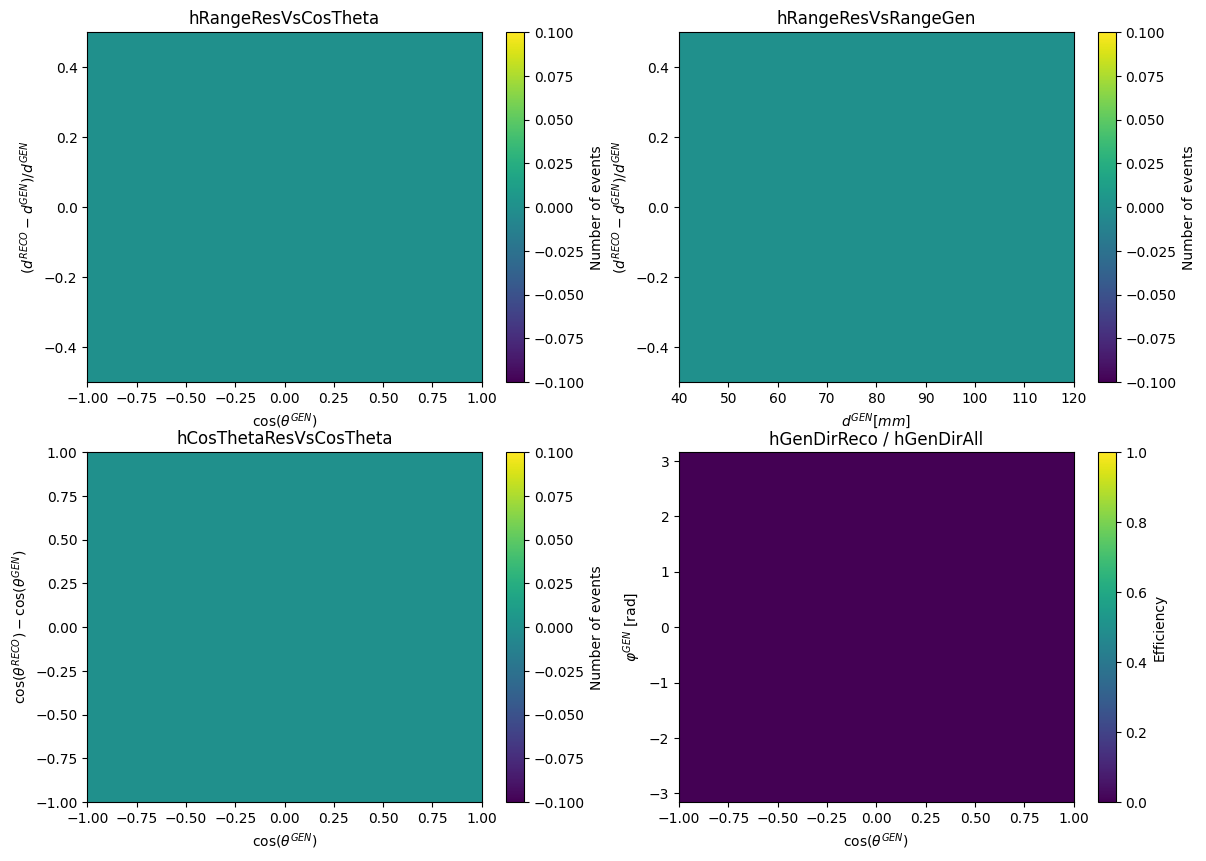

In [ ]:
# MCPlots_set0.png
# create subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# subplot 1
x = df_fiducial['cosThetaGen']
y = (df_fiducial['alphaRangeReco'] - df_fiducial['alphaRangeGen']) / df_fiducial['alphaRangeGen']

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 81],
    range=[[-1, 1], [-0.5, 0.5]]
)

im = axes[0,0].imshow(
    H.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis"
)
fig.colorbar(im, ax=axes[0,0], label="Number of events")
axes[0,0].set_xlabel(r"$\cos(\theta^{GEN})$")
axes[0,0].set_ylabel(r"$(d^{RECO} - d^{GEN})/d^{GEN}$")
axes[0,0].set_title("hRangeResVsCosTheta")
axes[0,0].margins(x=0.05, y=0.05)


# subplot 2
x = df_fiducial["alphaRangeGen"]
y = (df_fiducial["alphaRangeReco"] - df_fiducial["alphaRangeGen"]) / df_fiducial["alphaRangeGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 81],
    range=[[40, 120], [-0.5, 0.5]]
)

im = axes[0,1].imshow(
    H.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis"
)
fig.colorbar(im, ax=axes[0,1], label="Number of events")
axes[0,1].set_xlabel(r"$d^{GEN} [mm]$")
axes[0,1].set_ylabel(r"$(d^{RECO} - d^{GEN})/d^{GEN}$")
axes[0,1].set_title("hRangeResVsRangeGen")
axes[0,1].margins(x=0.05, y=0.05)

# subplot 3
x = df_fiducial["cosThetaGen"]
y = df_fiducial["cosThetaReco"] - df_fiducial["cosThetaGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 161],
    range=[[-1, 1], [-1, 1]]
)

im = axes[1,0].imshow(
    H.T,                   # transpose because imshow expects (rows=y, cols=x)
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis"
)

fig.colorbar(im, ax=axes[1,0], label="Number of events")
axes[1,0].set_xlabel(r"$\cos(\theta^{GEN})$")
axes[1,0].set_ylabel(r"$\cos(\theta^{RECO}) - \cos(\theta^{GEN})$")
axes[1,0].set_title("hCosThetaResVsCosTheta")
axes[1,0].margins(x=0.05, y=0.05)


# subplot 4
x_all = df_fiducial["cosThetaGen"]
y_all = df_fiducial["phiGen"]

x_reco = df_selected["cosThetaGen"]
y_reco = df_selected["phiGen"]

H_all, xedges, yedges = np.histogram2d(
    x_all, y_all,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

H_reco, _, _ = np.histogram2d(
    x_reco, y_reco,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

# Efficiency = reco / all (avoid divide-by-zero)
efficiency = np.divide(H_reco, H_all, out=np.zeros_like(H_reco, dtype=float), where=H_all>0)

im = axes[1,1].imshow(
    efficiency.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0
)

fig.colorbar(im, ax=axes[1,1], label="Efficiency")
axes[1,1].set_xlabel(r"$\cos(\theta^{GEN})$")
axes[1,1].set_ylabel(r"$\varphi^{GEN}$ [rad]")
axes[1,1].set_title("hGenDirReco / hGenDirAll")
axes[1,1].margins(x=0.05, y=0.05)

if save_fig_to_directory:
    fig.savefig(output_dir + '/MCPlots_set0.png')


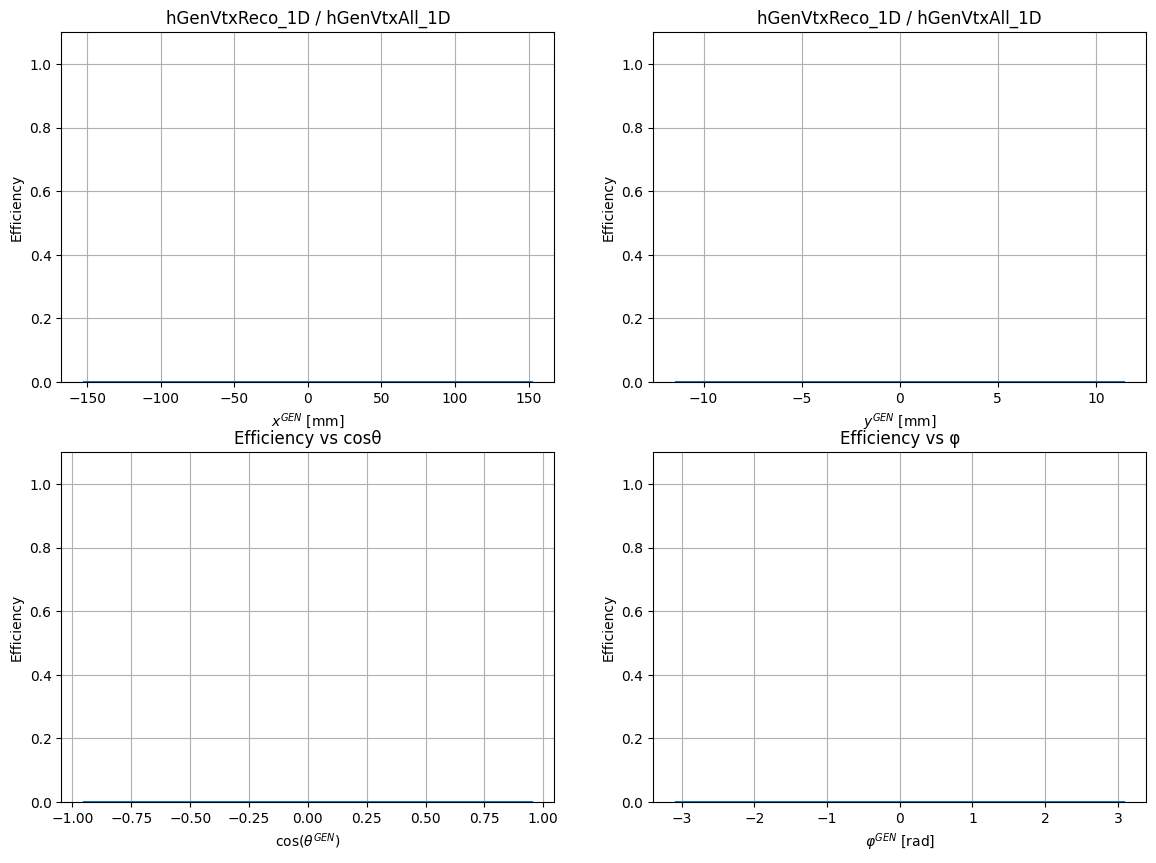

In [53]:
# MCPlots_set1.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# figure 1
x_all = df_fiducial["vtxGenX"]
y_all = df_fiducial["vtxGenY"]

x_reco = df_selected["vtxGenX"]
y_reco = df_selected["vtxGenY"]

H_all, xedges, yedges = np.histogram2d(
    x_all, y_all,
    bins=[21, 21],
    range=[[-160, 160], [-12, 12]]
)

H_reco, _, _ = np.histogram2d(
    x_reco, y_reco,
    bins=[21, 21],
    range=[[-160, 160], [-12, 12]]
)

# ProjectionX = sum over Y axis (axis=1 in numpy)
proj_all = H_all.sum(axis=1)
proj_reco = H_reco.sum(axis=1)

# Efficiency = reco / all (bin by bin)
efficiency = np.divide(proj_reco, proj_all, out=np.zeros_like(proj_reco, dtype=float), where=proj_all>0)

# Bin centers for plotting
x_centers = 0.5 * (xedges[:-1] + xedges[1:])

axes[0,0].plot(x_centers, efficiency, drawstyle="steps-mid")
axes[0,0].set_xlabel(r"$x^{GEN}$ [mm]")
axes[0,0].set_ylabel("Efficiency")
axes[0,0].set_ylim(0.0, 1.1)
axes[0,0].set_title("hGenVtxReco_1D / hGenVtxAll_1D")
axes[0,0].grid(True)


# fig 2
x_all = df_fiducial["vtxGenX"]
y_all = df_fiducial["vtxGenY"]

x_reco = df_selected["vtxGenX"]
y_reco = df_selected["vtxGenY"]

H_all, xedges, yedges = np.histogram2d(
    x_all, y_all,
    bins=[21, 21],
    range=[[-160, 160], [-12, 12]]
)

H_reco, _, _ = np.histogram2d(
    x_reco, y_reco,
    bins=[21, 21],
    range=[[-160, 160], [-12, 12]]
)

proj_all = H_all.sum(axis=0)
proj_reco = H_reco.sum(axis=0)

efficiency = np.divide(proj_reco, proj_all, out=np.zeros_like(proj_reco, dtype=float), where=proj_all>0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[0,1].plot(y_centers, efficiency, drawstyle="steps-mid")
axes[0,1].set_xlabel(r"$y^{GEN}$ [mm]")
axes[0,1].set_ylabel("Efficiency")
axes[0,1].set_ylim(0.0, 1.1)
axes[0,1].set_title("hGenVtxReco_1D / hGenVtxAll_1D")
axes[0,1].grid(True)


# fig 3
x_all = df_fiducial["cosThetaGen"]
y_all = df_fiducial["phiGen"]

x_reco = df_selected["cosThetaGen"]
y_reco = df_selected["phiGen"]

H_all, xedges, yedges = np.histogram2d(
    x_all, y_all,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

H_reco, _, _ = np.histogram2d(
    x_reco, y_reco,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

proj_all = H_all.sum(axis=1)
proj_reco = H_reco.sum(axis=1)

efficiency = np.divide(proj_reco, proj_all, out=np.zeros_like(proj_reco, dtype=float), where=proj_all>0)

x_centers = 0.5 * (xedges[:-1] + xedges[1:])

axes[1,0].plot(x_centers, efficiency, drawstyle="steps-mid")
axes[1,0].set_xlabel(r"$\cos(\theta^{GEN})$")
axes[1,0].set_ylabel("Efficiency")
axes[1,0].set_ylim(0.0, 1.1)
axes[1,0].set_title("Efficiency vs cosθ")
axes[1,0].grid(True)


# fig 4
x_all = df_fiducial["cosThetaGen"]
y_all = df_fiducial["phiGen"]

x_reco = df_selected["cosThetaGen"]
y_reco = df_selected["phiGen"]

H_all, xedges, yedges = np.histogram2d(
    x_all, y_all,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

H_reco, _, _ = np.histogram2d(
    x_reco, y_reco,
    bins=[21, 41],
    range=[[-1, 1], [-3.16, 3.16]]
)

proj_all = H_all.sum(axis=0)
proj_reco = H_reco.sum(axis=0)

efficiency = np.divide(proj_reco, proj_all, out=np.zeros_like(proj_reco, dtype=float), where=proj_all>0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[1, 1].plot(y_centers, efficiency, drawstyle="steps-mid")
axes[1, 1].set_xlabel(r"$\varphi^{GEN}$ [rad]")
axes[1, 1].set_ylabel("Efficiency")
axes[1, 1].set_ylim(0.0, 1.1)
axes[1, 1].set_title("Efficiency vs φ")
axes[1, 1].grid(True)

if save_fig_to_directory:
    fig.savefig(output_dir + '/MCPlots_set1.png')

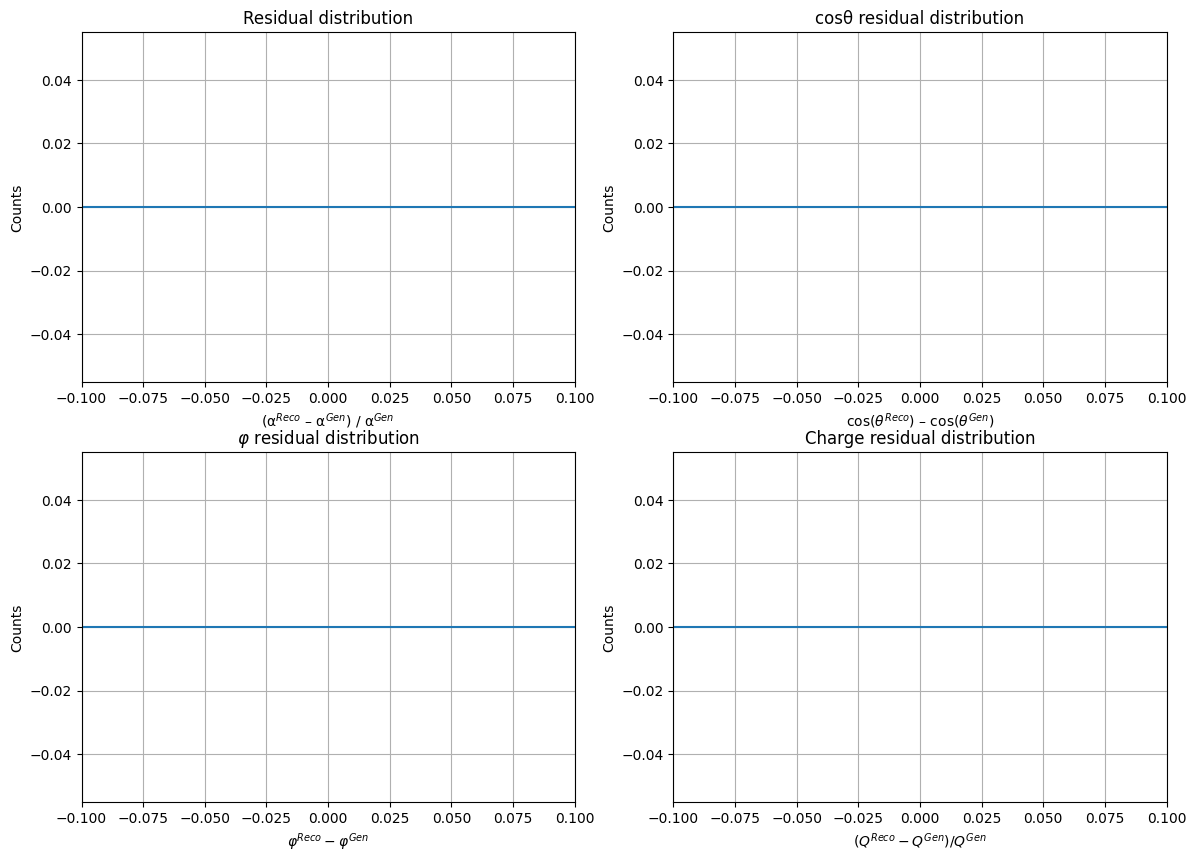

In [54]:
# MCPlots_set2.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# figure 1
x = df_fiducial["cosThetaGen"]
y = (df_fiducial["alphaRangeReco"] - df_fiducial["alphaRangeGen"]) / df_fiducial["alphaRangeGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 81],
    range=[[-1, 1], [-0.5, 0.5]]
)

proj_y = H.sum(axis=0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[0, 0].plot(y_centers, proj_y, drawstyle="steps-mid")
axes[0, 0].set_xlabel(r"(α$^{Reco}$ – α$^{Gen}$) / α$^{Gen}$")
axes[0, 0].set_ylabel("Counts")
axes[0, 0].set_xlim(-0.1, 0.1)
axes[0, 0].grid(True)
axes[0, 0].set_title("Residual distribution")


# figure 2
x = df_fiducial["cosThetaGen"]
y = df_fiducial["cosThetaReco"] - df_fiducial["cosThetaGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 161],
    range=[[-1, 1], [-1, 1]]
)

proj_y = H.sum(axis=0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[0, 1].plot(y_centers, proj_y, drawstyle="steps-mid")
axes[0, 1].set_xlabel(r"cos($\theta^{Reco}$) – cos($\theta^{Gen}$)")
axes[0, 1].set_ylabel("Counts")
axes[0, 1].set_xlim(-0.1, 0.1)
axes[0, 1].grid(True)
axes[0, 1].set_title("cosθ residual distribution")


# figure 3
x = df_fiducial["cosThetaGen"]
y = df_fiducial["phiReco"] - df_fiducial["phiGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 81],
    range=[[-1, 1], [-0.5, 0.5]]
)

proj_y = H.sum(axis=0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[1, 0].plot(y_centers, proj_y, drawstyle="steps-mid")
axes[1, 0].set_xlabel(r"$\varphi^{Reco} - \varphi^{Gen}$")
axes[1, 0].set_ylabel("Counts")
axes[1, 0].set_xlim(-0.1, 0.1)
axes[1, 0].grid(True)
axes[1, 0].set_title(r"$\varphi$ residual distribution")


# figure 4
x = df_fiducial["cosThetaGen"]
y = (df_fiducial["chargeReco"] - df_fiducial["chargeGen"]) / df_fiducial["chargeGen"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 81],
    range=[[-1, 1], [-1, 1]]
)

proj_y = H.sum(axis=0)

y_centers = 0.5 * (yedges[:-1] + yedges[1:])

axes[1, 1].plot(y_centers, proj_y, drawstyle="steps-mid")
axes[1, 1].set_xlabel(r"$(Q^{Reco} - Q^{Gen}) / Q^{Gen}$")
axes[1, 1].set_ylabel("Counts")
axes[1, 1].set_xlim(-0.1, 0.1)
axes[1, 1].grid(True)
axes[1, 1].set_title("Charge residual distribution")

if save_fig_to_directory:
    fig.savefig(output_dir + '/MCPlots_set2.png')


/tmp/ipykernel_330094/1457445334.py:92: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, 1.2 * ymax)


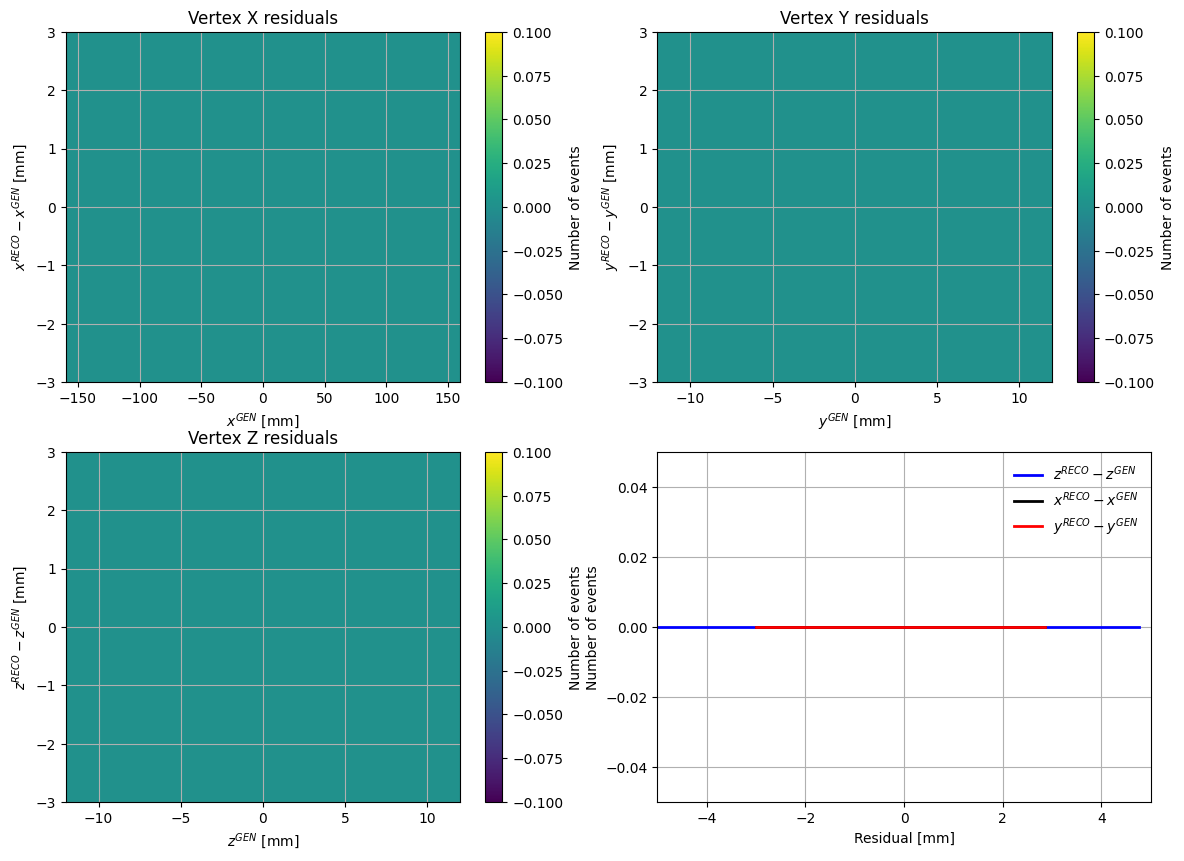

In [55]:
# MCPlots_set3.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# fig 1
x = df_fiducial["vtxGenX"]
y = df_fiducial["vtxRecoX"] - df_fiducial["vtxGenX"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 41],
    range=[[-160, 160], [-3, 3]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[0, 0].pcolormesh(X, Y, H.T, shading="auto")

axes[0, 0].set_xlabel(r"$x^{GEN}$ [mm]")
axes[0, 0].set_ylabel(r"$x^{RECO} - x^{GEN}$ [mm]")
axes[0, 0].set_title("Vertex X residuals")
axes[0, 0].grid(True)

fig.colorbar(pcm, ax=axes[0, 0], label="Number of events")

# fig 2
x = df_fiducial["vtxGenY"]
y = df_fiducial["vtxRecoY"] - df_fiducial["vtxGenY"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 41],
    range=[[-12, 12], [-3, 3]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[0, 1].pcolormesh(X, Y, H.T, shading="auto")

axes[0, 1].set_xlabel(r"$y^{GEN}$ [mm]")
axes[0, 1].set_ylabel(r"$y^{RECO} - y^{GEN}$ [mm]")
axes[0, 1].set_title("Vertex Y residuals")
axes[0, 1].grid(True)

fig.colorbar(pcm, ax=axes[0, 1], label="Number of events")


# fig 3
x = df_fiducial["vtxGenZ"]
y = df_fiducial["vtxRecoZ"] - df_fiducial["vtxGenZ"]

H, xedges, yedges = np.histogram2d(
    x, y,
    bins=[21, 41],
    range=[[-12, 12], [-3, 3]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[1, 0].pcolormesh(X, Y, H.T, shading="auto")

axes[1, 0].set_xlabel(r"$z^{GEN}$ [mm]")
axes[1, 0].set_ylabel(r"$z^{RECO} - z^{GEN}$ [mm]")
axes[1, 0].set_title("Vertex Z residuals")
axes[1, 0].grid(True)

fig.colorbar(pcm, ax=axes[1, 0], label="Number of events")


# fig 4
# --- Compute residuals ---
res_x = df_fiducial["vtxRecoX"] - df_fiducial["vtxGenX"]
res_y = df_fiducial["vtxRecoY"] - df_fiducial["vtxGenY"]
res_z = df_fiducial["vtxRecoZ"] - df_fiducial["vtxGenZ"]

# --- Create histograms (projections Y in ROOT language) ---
counts_z, bins_z = np.histogram(res_z, bins=41, range=(-5, 5))
counts_x, bins_x = np.histogram(res_x, bins=41, range=(-3, 3))
counts_y, bins_y = np.histogram(res_y, bins=41, range=(-3, 3))

# --- Plot on the same axes ---
ax = axes[1, 1]   # bottom-right panel in 2x2 layout

ax.step(bins_z[:-1], counts_z, where="mid", color="blue", linewidth=2, label=r"$z^{RECO} - z^{GEN}$")
ax.step(bins_x[:-1], counts_x, where="mid", color="black", linewidth=2, label=r"$x^{RECO} - x^{GEN}$")
ax.step(bins_y[:-1], counts_y, where="mid", color="red", linewidth=2, label=r"$y^{RECO} - y^{GEN}$")

# --- Style ---
ax.set_xlim(-5, 5)  # matches ROOT's SetRangeUser(-5,5) for Z residual
ax.set_xlabel("Residual [mm]")
ax.set_ylabel("Number of events")
ax.grid(True)

# Scale Y axis like ROOT's SetMaximum(1.2*max)
ymax = max(counts_x.max(), counts_y.max(), counts_z.max())
ax.set_ylim(0, 1.2 * ymax)

# Legend
ax.legend(loc="upper right", frameon=False)


if save_fig_to_directory:
    fig.savefig(output_dir + '/MCPlots_set3.png')

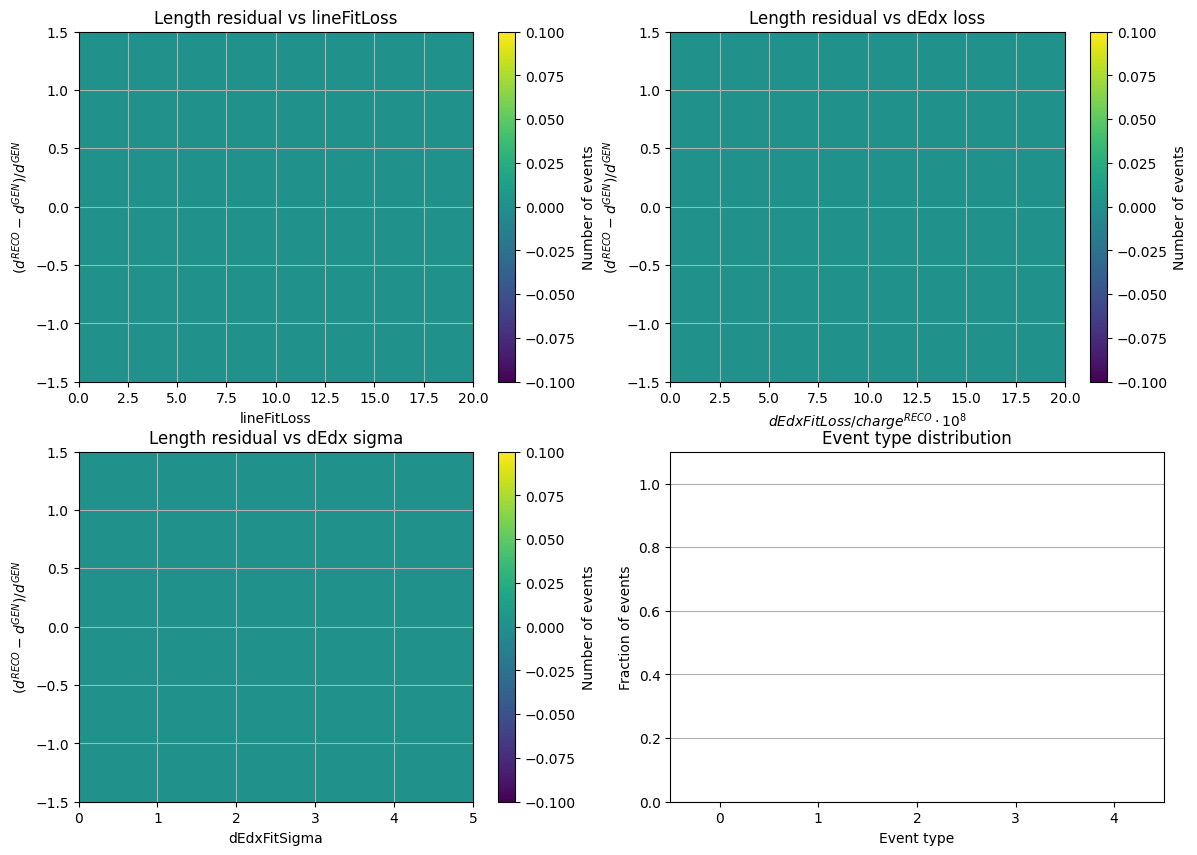

In [56]:
# MCPlots_set4.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# fig 1
# --- Compute relative residuals ---
length_res = (df_fiducial["alphaRangeReco"] - df_fiducial["alphaRangeGen"]) / df_fiducial["alphaRangeGen"]
line_loss  = df_fiducial["lineFitLoss"]

# --- 2D histogram on axes[0,0] ---
H, xedges, yedges = np.histogram2d(
    line_loss, length_res,
    bins=[21, 41],
    range=[[0, 20], [-1.5, 1.5]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[0, 0].pcolormesh(X, Y, H.T, shading="auto", cmap="viridis")

# --- Style ---
axes[0, 0].set_xlabel("lineFitLoss")
axes[0, 0].set_ylabel(r"$(d^{RECO} - d^{GEN}) / d^{GEN}$")
axes[0, 0].set_title("Length residual vs lineFitLoss")
axes[0, 0].grid(True)

# --- Colorbar ---
fig.colorbar(pcm, ax=axes[0, 0], label="Number of events")


# fig 2
length_res = (df_fiducial["alphaRangeReco"] - df_fiducial["alphaRangeGen"]) / df_fiducial["alphaRangeGen"]
dedx_loss  = df_fiducial["dEdxFitLoss"] / df_fiducial["chargeReco"] * 1e8

H, xedges, yedges = np.histogram2d(
    dedx_loss, length_res,
    bins=[21, 41],
    range=[[0, 20], [-1.5, 1.5]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[0, 1].pcolormesh(X, Y, H.T, shading="auto", cmap="viridis")

axes[0, 1].set_xlabel(r"$dEdxFitLoss / charge^{RECO} \cdot 10^8$")
axes[0, 1].set_ylabel(r"$(d^{RECO} - d^{GEN}) / d^{GEN}$")
axes[0, 1].set_title("Length residual vs dEdx loss")
axes[0, 1].grid(True)

fig.colorbar(pcm, ax=axes[0, 1], label="Number of events")


# fig 3
# --- Compute relative residuals and dEdx sigma ---
length_res = (df_fiducial["alphaRangeReco"] - df_fiducial["alphaRangeGen"]) / df_fiducial["alphaRangeGen"]
dedx_sigma = df_fiducial["dEdxFitSigma"]

# --- 2D histogram ---
H, xedges, yedges = np.histogram2d(
    dedx_sigma, length_res,
    bins=[21, 41],
    range=[[0, 5], [-1.5, 1.5]]
)

X, Y = np.meshgrid(xedges, yedges)
pcm = axes[1, 0].pcolormesh(X, Y, H.T, shading="auto", cmap="viridis")

# --- Style ---
axes[1, 0].set_xlabel("dEdxFitSigma")
axes[1, 0].set_ylabel(r"$(d^{RECO} - d^{GEN}) / d^{GEN}$")
axes[1, 0].set_title("Length residual vs dEdx sigma")
axes[1, 0].grid(True)

# --- Colorbar ---
fig.colorbar(pcm, ax=axes[1, 0], label="Number of events")


# fig 4
# --- Histogram of eventTypeReco ---
event_type_counts = df_fiducial["eventTypeReco"].value_counts().sort_index()
event_type_bins = np.arange(-0.5, 5.5, 1)  # 5 bins: [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

# --- Normalize to get fractions ---
event_type_frac = event_type_counts / event_type_counts.sum()

# --- Bar plot ---
ax = axes[1, 1]
bars = ax.bar(event_type_frac.index, event_type_frac.values, width=1.0, align='center', color='skyblue', edgecolor='black')

# --- Add text labels on top of each bar ---
for bar, frac in zip(bars, event_type_frac.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{frac:.2f}", ha='center', va='bottom', fontsize=10)

# --- Style ---
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Event type")
ax.set_ylabel("Fraction of events")
ax.set_title("Event type distribution")
ax.grid(True, axis='y')

if save_fig_to_directory:
    fig.savefig(output_dir + '/MCPlots_set4.png')